# IBM Telco Customer Churn — Exploratory Data Analysis

This notebook explores the **real** IBM Telco Customer Churn dataset that powers the
decision engine. The goal is to understand *what drives churn* before modeling — and
to sanity-check the economic assumptions (contract, tenure, monthly charges) that the
CLV and retention-cost formulas rely on.

Run the data pipeline first (`python -m src.pipeline`) so the cleaned data is available.

In [1]:
import sys
from pathlib import Path

# Make the project importable when running from notebooks/
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.economics import add_economic_fields
from src.ingest import clean_telco_data
from src.config import RAW_DATA_PATH

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "font.size": 11,
})
ACCENT = "#3987e5"

raw = pd.read_csv(RAW_DATA_PATH)
df = add_economic_fields(clean_telco_data(raw))
print(f"{len(df):,} customers, {df['churned'].mean():.1%} overall churn rate")
df[["customer_id", "Contract", "tenure", "MonthlyCharges", "churned", "CLV", "retention_cost"]].head()

7,043 customers, 26.5% overall churn rate


,customer_id,Contract,tenure,MonthlyCharges,churned,CLV,retention_cost
0,7590-VHVEG,Month-to-month,1,29.85,0,363.175000,36.865
1,5575-GNVDE,One year,34,56.95,0,2012.233333,76.255
2,3668-QPYBK,Month-to-month,2,53.85,1,664.150000,58.465
3,7795-CFOCW,One year,45,42.30,0,1649.700000,63.070
4,9237-HQITU,Month-to-month,2,70.70,1,871.966667,73.630


## 1. Overall churn balance

Churn is the target. About 1 in 4 customers churn — a moderately imbalanced problem,
which is why we look at ROC AUC and calibration rather than raw accuracy (a
"predict nobody churns" baseline already scores ~73%).

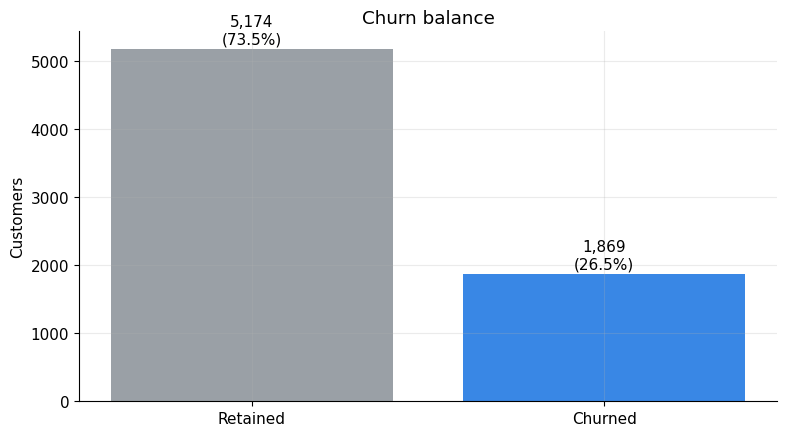

In [2]:
counts = df["churned"].value_counts().sort_index()
labels = ["Retained", "Churned"]
fig, ax = plt.subplots()
ax.bar(labels, counts.values, color=["#9aa0a6", ACCENT])
for i, v in enumerate(counts.values):
    ax.text(i, v + 40, f"{v:,}\n({v/len(df):.1%})", ha="center", va="bottom")
ax.set_ylabel("Customers"); ax.set_title("Churn balance")
plt.tight_layout(); plt.show()

## 2. Churn by contract type

The single strongest driver. Month-to-month customers churn at ~43%, two-year
customers at ~3%. This is exactly why the CLV model anchors expected lifetime on
contract type.

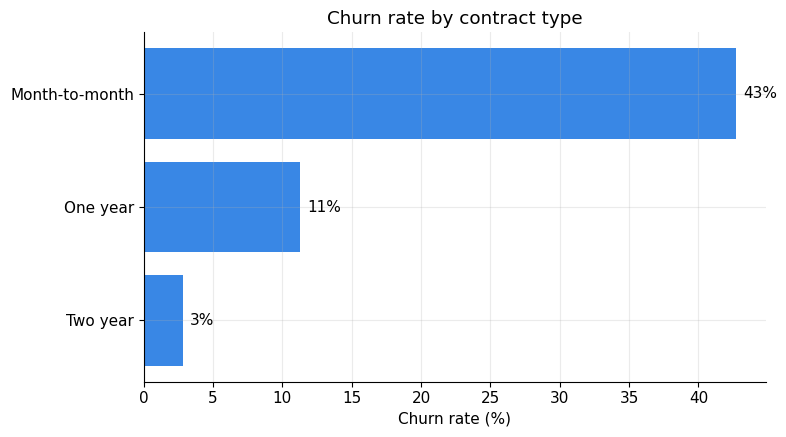

In [3]:
by_contract = df.groupby("Contract")["churned"].mean().sort_values(ascending=False)
fig, ax = plt.subplots()
ax.barh(by_contract.index, by_contract.values * 100, color=ACCENT)
for i, v in enumerate(by_contract.values * 100):
    ax.text(v + 0.5, i, f"{v:.0f}%", va="center")
ax.set_xlabel("Churn rate (%)"); ax.set_title("Churn rate by contract type")
ax.invert_yaxis(); plt.tight_layout(); plt.show()

## 3. Churn declines with tenure

New customers churn heavily; long-tenured customers rarely do. This validates using
tenure as a loyalty multiplier in the CLV formula.

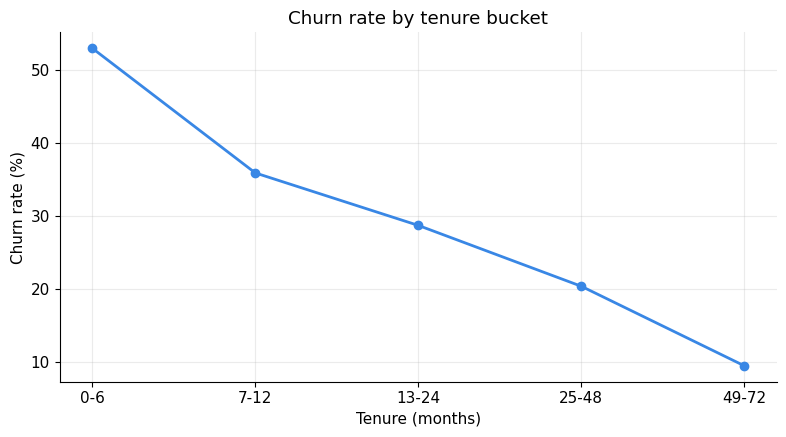

In [4]:
bins = [0, 6, 12, 24, 48, 72]
labels = ["0-6", "7-12", "13-24", "25-48", "49-72"]
df["tenure_bin"] = pd.cut(df["tenure"], bins=bins, labels=labels, include_lowest=True)
by_tenure = df.groupby("tenure_bin", observed=True)["churned"].mean()
fig, ax = plt.subplots()
ax.plot(by_tenure.index.astype(str), by_tenure.values * 100, marker="o", color=ACCENT, lw=2)
ax.set_xlabel("Tenure (months)"); ax.set_ylabel("Churn rate (%)")
ax.set_title("Churn rate by tenure bucket"); plt.tight_layout(); plt.show()

## 4. Monthly charges: churners pay more

Churners skew toward higher monthly charges (often fiber-optic customers on
month-to-month plans). Higher charges mean more revenue at risk — which the decision
engine weighs via `revenue_at_risk = p(churn) * CLV`.

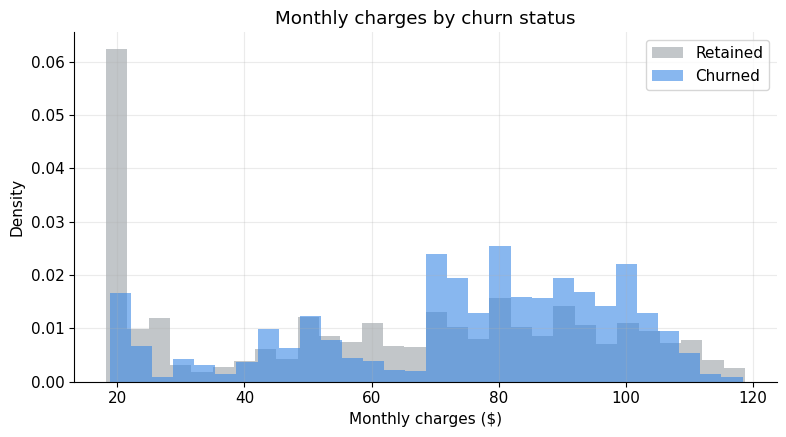

In [5]:
fig, ax = plt.subplots()
ax.hist(df.loc[df.churned == 0, "MonthlyCharges"], bins=30, alpha=0.6,
        label="Retained", color="#9aa0a6", density=True)
ax.hist(df.loc[df.churned == 1, "MonthlyCharges"], bins=30, alpha=0.6,
        label="Churned", color=ACCENT, density=True)
ax.set_xlabel("Monthly charges ($)"); ax.set_ylabel("Density")
ax.set_title("Monthly charges by churn status"); ax.legend()
plt.tight_layout(); plt.show()

## 5. Churn by key services

Customers *without* online security or tech support churn far more — actionable
levers a retention team could pull (upsell protective add-ons).

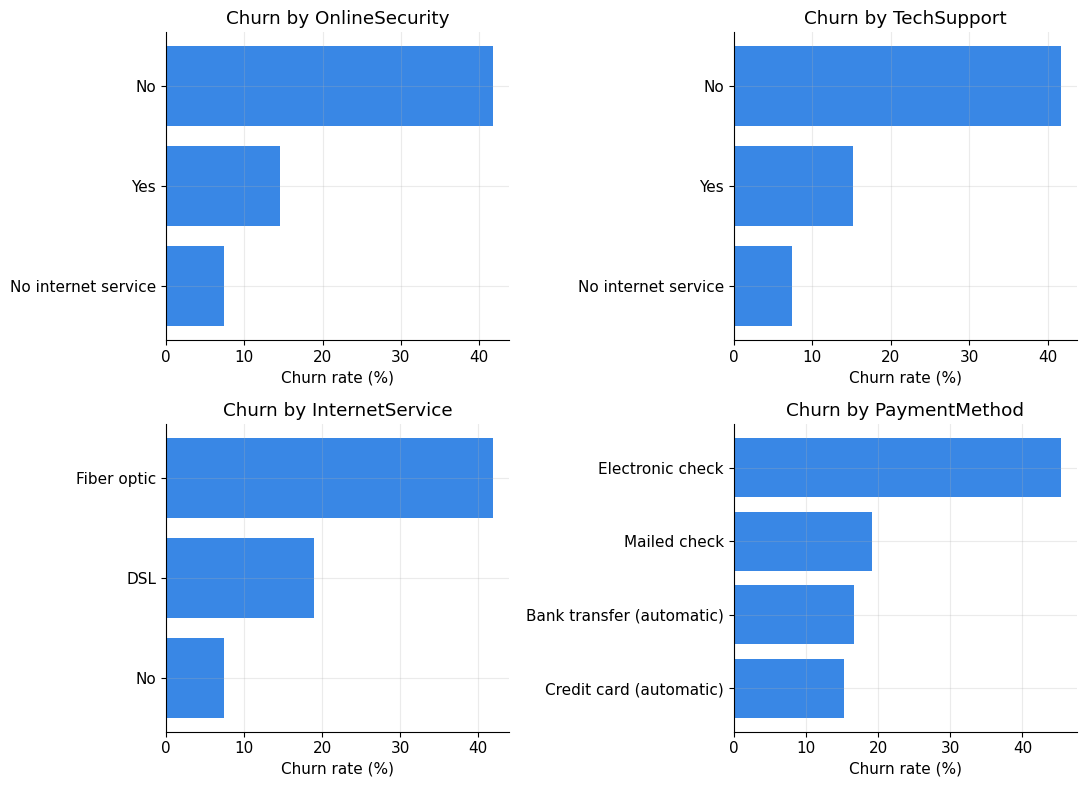

In [6]:
services = ["OnlineSecurity", "TechSupport", "InternetService", "PaymentMethod"]
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.ravel(), services):
    rates = df.groupby(col)["churned"].mean().sort_values() * 100
    ax.barh(rates.index.astype(str), rates.values, color=ACCENT)
    ax.set_title(f"Churn by {col}"); ax.set_xlabel("Churn rate (%)")
plt.tight_layout(); plt.show()

## 6. Derived economics sanity check

The CLV and retention-cost fields are model *outputs*, not inputs. A quick check that
they behave sensibly: CLV rises with contract length, and retention cost varies
per customer (the bug the old synthetic generator had).

In [7]:
summary = df.groupby("Contract").agg(
    customers=("customer_id", "size"),
    churn_rate=("churned", "mean"),
    avg_mrr=("MRR", "mean"),
    avg_clv=("CLV", "mean"),
    retention_cost_spread=("retention_cost", lambda s: s.max() - s.min()),
).round(2)
summary

,customers,churn_rate,avg_mrr,avg_clv,retention_cost_spread
Contract,,,,,
Month-to-month,3875,0.43,66.40,1025.13,88.83
One year,1473,0.11,65.05,2571.11,90.32
Two year,1695,0.03,60.77,4041.11,90.32


### Takeaways for modeling

- **Contract, tenure, and internet/service add-ons** are the dominant churn signals —
  all captured in the feature set.
- Churn is **~27%**, so calibration and AUC matter more than accuracy.
- The economic derivations (CLV up with contract length, retention cost varying per
  customer) behave as intended.

Next: `src/pipeline.py` trains the logistic-regression model on these features and the
dashboard turns its probabilities into budget-constrained retention decisions.